# Using Pretrained Models

This notebook evaluates a pretrained DMRI model on held-out synthetic data. It demonstrates the complete inference workflow without rebuilding the architecture by hand:

1. restore the model and its EMA parameters from a checkpoint,
2. recreate the matching simulator from the saved Hydra config,
3. evaluate model-selection accuracy and negative log probability,
4. inspect parameter uncertainty and posterior-predictive coverage.

> The metrics below are computed on simulated, in-distribution data. They assess consistency with the training distribution and do not constitute validation on independent clinical data.

## 1. Restore a pretrained run

`load_checkpoint` reads the frozen `.hydra/config.yaml`, reconstructs the correct network and simulator family, and restores the requested Orbax checkpoint. EMA parameters are preferred for inference when available.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx
from omegaconf import OmegaConf

from dmri.train.build_simulator import build_simulator
from dmri.train.utils import load_checkpoint


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find the dmri project root.")


CHECKPOINT_NAME = "b3s_2_4_6_128"
HF_REPO_ID = "manugloeck/dmri-pretrained"

if HF_REPO_ID:
    checkpoint, model, simulator_model = load_checkpoint(
        repo_id=HF_REPO_ID, model_name=CHECKPOINT_NAME, which="best"
    )
else:
    checkpoint_dir = find_project_root() / "results" / CHECKPOINT_NAME
    checkpoint, model, simulator_model = load_checkpoint(checkpoint_dir, which="best")

params = (
    checkpoint["params_ema"] if "params_ema" in checkpoint else checkpoint["params"]
)
nnx.update(model, params)
model.eval()

sim_type = simulator_model
n_params = sum(p.size for p in jax.tree.leaves(nnx.state(model, nnx.Param)))
print(f"run:        {CHECKPOINT_NAME}")
print(f"step:       {checkpoint['step']:,}")
print(f"parameters: {n_params / 1e6:.1f}M")
print(f"theta dim:  {sim_type.theta_dim}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 118 files:   0%|          | 0/118 [00:00<?, ?it/s]

run:        b3s_2_4_6_128
step:       1,800,000
parameters: 6.7M
theta dim:  11


## 2. Create a held-out evaluation set

`load_checkpoint` returns the simulator model class, not a training-data generator. For this synthetic example we pair that class with an explicit 105-measurement HCP acquisition. Check the saved training config before choosing an acquisition for a real checkpoint.

In [2]:
num_eval = 128
simulator_path = f"{sim_type.__module__}.{sim_type.__qualname__}"
simulation_cfg = OmegaConf.create({
    "simulator": {
        "model_class": simulator_path,
        "posterior_score": False,
        "mask_prior": {},
        "acquisitions": [
            {
                "_target_": "dmri.simulators.random_hcp_acquisition",
                "_partial_": True,
                "num_acquisitions": 105,
                "typical_prob": 1.0,
                "random_prob": 0.0,
            }
        ],
    }
})
_, (simulator,) = build_simulator(simulation_cfg)
eval_batch = jax.jit(jax.vmap(simulator))(
    jax.random.split(jax.random.key(10), num_eval)
)

raw_names = [cls.__name__ for cls in (*sim_type.model_types, *sim_type.noise_types)]
component_names = []
for i, name in enumerate(raw_names):
    count = raw_names.count(name)
    occurrence = raw_names[: i + 1].count(name)
    component_names.append(f"{name} {occurrence}" if count > 1 else name)

print({k: value.shape for k, value in eval_batch.items() if k != "acq"})
print("components:", component_names)

{'mask_prior': (128, 1), 'model_mask': (128, 5), 'theta': (128, 11), 'x': (128, 105)}
components: ['StaticBall', 'StaticStick 1', 'StaticStick 2', 'StaticStick 3', 'BoundedGaussianNoise']


## 3. Evaluate model selection

The three `StaticStick` slots are exchangeable: permuting active sticks does not change the physical model. We therefore group the 15 feasible labeled masks into seven identifiable classes defined by ball presence and stick count.

For each observation, the learned mask posterior is divided by the exact mask prior. If the learned posterior is calibrated, this ratio is proportional to relative model evidence. Evidence is averaged across exchangeable labels so that classes with more stick permutations do not receive additional weight. Concentration near the diagonal indicates recovery of the generating class; off-diagonal values indicate support for alternative classes.

In [3]:
# Enumerate all non-empty signal masks; Gaussian noise is always active.
signal_masks = ((jnp.arange(16)[:, None] >> jnp.arange(4)) & 1).astype(bool)
signal_masks = signal_masks[signal_masks.any(axis=1)]
feasible_masks = jnp.column_stack([signal_masks, jnp.ones(15, dtype=bool)])


def model_class(mask):
    ball_present = mask[..., 0].astype(jnp.int32)
    stick_count = mask[..., 1:4].sum(axis=-1).astype(jnp.int32)
    return 4 * ball_present + stick_count


class_ids = jnp.arange(1, 8)
class_names = ["S", "2S", "3S", "B", "B+S", "B+2S", "B+3S"]
candidate_classes = model_class(feasible_masks)
mask_prior_dist = sim_type.create_mask_prior()


def score_observation(acq, x, mask_prior):
    log_posterior = jax.vmap(model.log_prob_mask, in_axes=(0, None, None, None))(
        feasible_masks, acq, x, mask_prior
    )
    log_prior = jax.vmap(mask_prior_dist.log_prob, in_axes=(0, None))(
        feasible_masks, mask_prior
    )
    mask_log_evidence = log_posterior - log_prior

    # Log-mean-exp removes the multiplicity advantage of exchangeable labels.
    class_log_evidence = jnp.stack([
        jax.scipy.special.logsumexp(
            jnp.where(candidate_classes == class_id, mask_log_evidence, -jnp.inf)
        )
        - jnp.log((candidate_classes == class_id).sum())
        for class_id in class_ids
    ])
    return mask_log_evidence, class_log_evidence


mask_log_evidence, class_log_evidence = jax.jit(jax.vmap(score_observation))(
    eval_batch["acq"],
    eval_batch["x"],
    eval_batch["mask_prior"],
)

true_classes = model_class(eval_batch["model_mask"])
pred_classes = class_ids[jnp.argmax(class_log_evidence, axis=1)]
class_matches = pred_classes == true_classes

true_scores = jnp.take_along_axis(
    class_log_evidence, (true_classes - 1)[:, None], axis=1
).squeeze(1)
alternatives = class_log_evidence.at[jnp.arange(num_eval), true_classes - 1].set(
    -jnp.inf
)
evidence_margin = true_scores - alternatives.max(axis=1)

exchangeable_classes = jnp.array([1, 2, 5, 6])
label_spread = jnp.stack([
    jnp.max(
        jnp.where(candidate_classes == class_id, mask_log_evidence, -jnp.inf), axis=1
    )
    - jnp.min(
        jnp.where(candidate_classes == class_id, mask_log_evidence, jnp.inf), axis=1
    )
    for class_id in exchangeable_classes
])

print(f"evidence-selected class accuracy: {class_matches.mean():.3f}")
print(f"mean true-class evidence margin:  {evidence_margin.mean():+.3f}")
print(f"mean exchangeable-label range:   {label_spread.mean():.3f}")

evidence-selected class accuracy: 0.508
mean true-class evidence margin:  +0.116
mean exchangeable-label range:   1.171


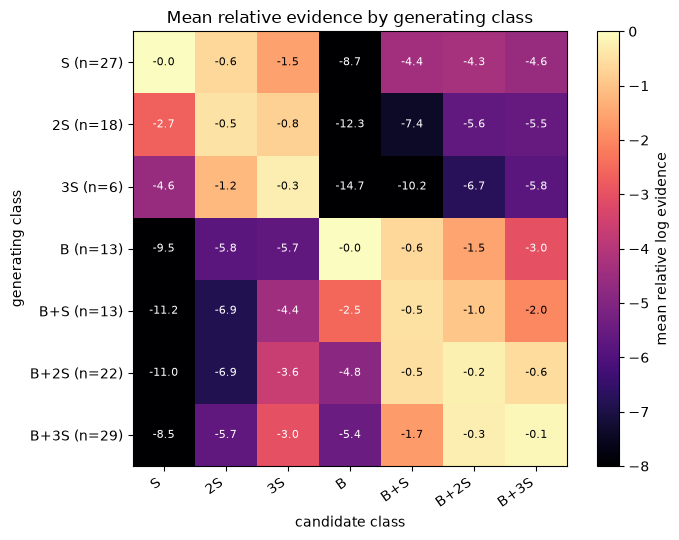

In [4]:
relative_evidence = class_log_evidence - class_log_evidence.max(axis=1, keepdims=True)
class_counts = jnp.array([(true_classes == class_id).sum() for class_id in class_ids])
mean_relative_evidence = jnp.stack([
    (relative_evidence * (true_classes == class_id)[:, None]).sum(axis=0)
    / jnp.maximum(class_counts[class_id - 1], 1)
    for class_id in class_ids
])

fig, ax = plt.subplots(figsize=(7.2, 5.5))
image = ax.imshow(mean_relative_evidence, cmap="magma", vmin=-8, vmax=0)
for row in range(7):
    for col in range(7):
        value = float(mean_relative_evidence[row, col])
        ax.text(
            col,
            row,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="white" if value < -2 else "black",
            fontsize=8,
        )
ax.set_xticks(range(7), class_names, rotation=35, ha="right")
ax.set_yticks(
    range(7),
    [
        f"{name} (n={int(count)})"
        for name, count in zip(class_names, class_counts, strict=True)
    ],
)
ax.set_xlabel("candidate class")
ax.set_ylabel("generating class")
ax.set_title("Mean relative evidence by generating class")
fig.colorbar(image, ax=ax, label="mean relative log evidence")
plt.tight_layout()

The matrix indicates separation between ball-absent and ball-present families. Evidence is distributed across neighboring stick-count classes, consistent with similarity among their simulated signals. The positive mean evidence margin indicates that the generating class receives the highest evidence on average. The non-zero range among exchangeable labels indicates residual sensitivity to stick ordering in the learned posterior.

## 4. Evaluate parameter uncertainty

To evaluate parameter inference separately from model selection, select a sample whose identifiable class was recovered and condition `sample_theta` on its known labeled mask. The plot compares the posterior median and 90% interval with the known simulator parameters.

In [5]:
active_components = eval_batch["model_mask"].sum(-1)
candidate_score = jnp.where(class_matches, active_components, -1)
sample_idx = int(jnp.argmax(candidate_score))

acq = jax.tree_util.tree_map(lambda value: value[sample_idx], eval_batch["acq"])
x = eval_batch["x"][sample_idx]
theta_true = eval_batch["theta"][sample_idx]
model_mask = eval_batch["model_mask"][sample_idx]

theta_samples = jax.vmap(
    lambda key: model.sample_theta(key, acq, x, model_mask, num_steps=64)
)(jax.random.split(jax.random.key(12), 256))

lower, median, upper = jnp.quantile(theta_samples, jnp.array([0.05, 0.5, 0.95]), axis=0)
coverage = ((theta_true >= lower) & (theta_true <= upper)).mean()
print(f"sample index:          {sample_idx}")
print(f"model mask:           {np.asarray(model_mask)}")
print(f"90% interval coverage: {coverage:.3f}")

sample index:          2
model mask:           [ True  True  True  True  True]
90% interval coverage: 1.000


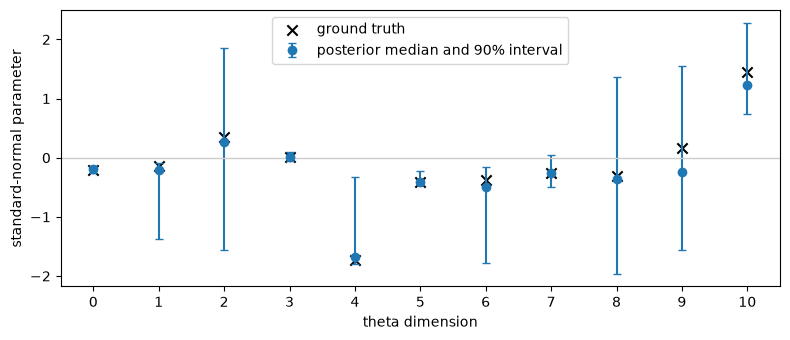

In [6]:
theta_index = np.arange(sim_type.theta_dim)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(
    theta_index,
    median,
    yerr=np.stack([median - lower, upper - median]),
    fmt="o",
    capsize=3,
    label="posterior median and 90% interval",
)
ax.scatter(
    theta_index, theta_true, color="black", marker="x", s=55, label="ground truth"
)
ax.axhline(0, color="0.8", lw=1)
ax.set_xlabel("theta dimension")
ax.set_ylabel("standard-normal parameter")
ax.set_xticks(theta_index)
ax.legend()
plt.tight_layout()

## 5. Posterior-predictive evaluation

Push posterior samples back through the physical simulator. The median and 90% predictive band should explain the observed signal across b-values.

posterior-predictive MSE: 0.00018


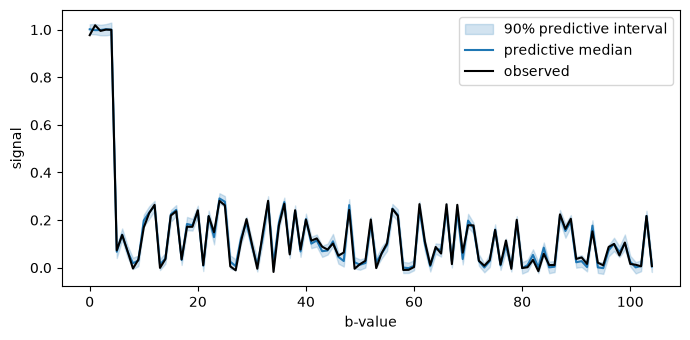

In [7]:
def predict_signal(theta, rng):
    physical_model = sim_type.from_theta(theta, model_mask=model_mask)
    return physical_model.signal(acq, rng=rng)


predictive = jax.vmap(predict_signal)(
    theta_samples[:100], jax.random.split(jax.random.key(13), 100)
)
pred_lower, pred_median, pred_upper = jnp.quantile(
    predictive, jnp.array([0.05, 0.5, 0.95]), axis=0
)
predictive_mse = jnp.mean((predictive.mean(0) - x) ** 2)
print(f"posterior-predictive MSE: {predictive_mse:.5f}")

order = jnp.argsort(acq.bvals)
bvals = np.asarray(acq.bvals)[order]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.fill_between(
    range(len(pred_lower[order])),
    pred_lower[order],
    pred_upper[order],
    color="C0",
    alpha=0.2,
    label="90% predictive interval",
)
ax.plot(pred_median[order], color="C0", lw=1.5, label="predictive median")
ax.plot(np.asarray(x)[order], color="black", lw=1.5, label="observed")
ax.set_xlabel("b-value")
ax.set_ylabel("signal")
ax.legend()
plt.tight_layout()

## Next steps

- Change `CHECKPOINT_NAME` to evaluate another compatible run; the loader reconstructs its architecture automatically.
- Use `which="latest"`, `which="best"`, or an integer step to choose the checkpoint.
- For NIfTI data, model averaging, SMC/MCMC correction, and metric exports, use `dmri eval` as described in the evaluation guide.
- The standalone training example shows how to train a small model on fresh simulations and evaluate its held-out predictions.